In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import json
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)


In [2]:
# PART 1: LOAD DATA
df = pd.read_excel("C:/Users/user/OneDrive/Desktop/airline_route_profitability.xlsx")
print(f"Loaded {len(df):,} flight records with {df.shape[1]} columns.")
df.head(10)

Loaded 7,974 flight records with 33 columns.


,Flight_Number,Flight_Date,Origin,Destination,Route,Aircraft_Type,Aircraft_Capacity,Passengers,Load_Factor,Flight_Hours,Season,Route_Category,Demand_Level,Ticket_Revenue,Ancillary_Revenue,Total_Revenue,Fuel_Cost,Maintenance_Cost,Crew_Cost,Depreciation_Cost,Insurance_Cost,Airport_Fees,Catering_Cost,Handling_Cost,Navigation_Fees,Sales_Distribution_Cost,Passenger_Service_Cost,Overhead_Cost,Marketing_Cost,IT_Systems_Cost,Total_Cost,Profit,Profit_Margin
0,EK8960,2024-12-20,DXB,ORD,DXB-ORD,Boeing 777-300ER,396,308,0.78,14.50,Peak,Long Haul,Medium,"410,785.49","53,431.94","464,217.43","131,033.88",50750,21750,65250,11600,"4,262.30","5,185.86","4,460.11","10,636.90","78,193.60","5,100.09","88,545.73","25,883.92","3,769.37","506,421.77","-42,204.34",-9.09
1,EK3960,2024-05-13,DXB,HYD,DXB-HYD,Boeing 787-9,296,234,0.79,4.20,Normal,Medium Haul,Medium,"145,890.17","17,695.27","163,585.44","21,338.76",9240,5040,13440,2520,"2,016.63","5,851.01","5,425.84","3,027.25","21,586.21","6,022.20","17,057.61","8,820.56","1,937.81","123,323.88","40,261.57",24.61
2,EK7529,2024-10-12,DXB,CDG,DXB-CDG,Boeing 787-9,296,251,0.85,7.50,Shoulder,Long Haul,High,"602,841.03","78,724.16","681,565.19","41,011.77",16500,9000,24000,4500,"10,764.79","4,134.08","3,761.85","3,431.70","100,188.97","6,514.22","31,347.38","23,695.34","3,415.99","282,266.09","399,299.10",58.59
3,EK4543,2024-06-25,DXB,DEL,DXB-DEL,Boeing 787-9,296,229,0.77,3.50,Low,Medium Haul,High,"126,485.16","17,543.26","144,028.42","17,333.86",7700,4200,11200,2100,"6,508.04","6,508.73","4,440.93","2,079.79","22,686.82","4,791.21","15,328.62","6,795.49","2,245.61","113,919.11","30,109.31",20.91
4,EK3114,2024-04-20,DXB,RUH,DXB-RUH,Airbus A320,180,142,0.79,2.20,Shoulder,Short Haul,Medium,"32,651.15","3,871.66","36,522.81","5,576.80",2530,1716,3740,616,"4,718.58","3,360.52","3,414.18","1,662.49","5,133.62","3,094.65","8,252.23","1,492.53","1,273.27","46,580.86","-10,058.06",-27.54
5,EK1737,2024-02-06,DXB,KWI,DXB-KWI,Airbus A320,180,171,0.95,2.00,Peak,Short Haul,High,"55,561.35","7,131.73","62,693.08","5,169.42",2300,1560,3400,560,"2,723.68","3,164.30","5,238.84","1,290.88","10,373.46","4,279.57","7,369.82","3,383.54","2,002.31","52,815.81","9,877.27",15.75
6,EK2566,2024-03-27,DXB,IST,DXB-IST,Boeing 787-9,296,281,0.95,5.00,Shoulder,Medium Haul,High,"197,209.86","25,550.13","222,759.99","29,311.03",11000,6000,16000,3000,"4,846.68","9,290.85","5,971.44","2,336.43","32,220.74","5,359.55","25,593.40","8,024.47","3,211.83","162,166.43","60,593.56",27.20
7,EK3653,2024-05-15,DXB,DOH,DXB-DOH,Boeing 737-800,189,148,0.78,1.50,Normal,Short Haul,High,"34,738.82","4,966.19","39,705.01","3,632.48",1800,1200,2700,450,"3,514.80","4,628.11","2,816.06",993.41,"6,653.68","3,184.82","5,579.27","1,500.80","1,325.46","39,978.91",-273.90,-0.69
8,EK8367,2024-12-25,DXB,KWI,DXB-KWI,Airbus A320,180,171,0.95,2.00,Peak,Short Haul,High,"57,630.63","6,379.85","64,010.49","4,521.15",2300,1560,3400,560,"2,852.17","4,760.32","5,166.24",886.93,"11,226.18","2,883.92","6,750.96","3,388.79","1,531.66","51,788.33","12,222.16",19.09
9,EK8561,2024-12-20,DXB,IST,DXB-IST,Boeing 787-9,296,281,0.95,5.00,Peak,Medium Haul,High,"244,854.25","25,076.13","269,930.38","26,145.38",11000,6000,16000,3000,"4,839.69","9,500.53","3,049.70","3,245.47","40,752.59","6,312.40","24,894.97","14,930.65","3,240.82","172,912.21","97,018.17",35.94


In [4]:
df.describe()

,Flight_Date,Aircraft_Capacity,Passengers,Load_Factor,Flight_Hours,Ticket_Revenue,Ancillary_Revenue,Total_Revenue,Fuel_Cost,Maintenance_Cost,Crew_Cost,Depreciation_Cost,Insurance_Cost,Airport_Fees,Catering_Cost,Handling_Cost,Navigation_Fees,Sales_Distribution_Cost,Passenger_Service_Cost,Overhead_Cost,Marketing_Cost,IT_Systems_Cost,Total_Cost,Profit,Profit_Margin
count,7974,"7,974.00","7,974.00","7,974.00","7,974.00","7,974.00","7,703.00","7,974.00","7,974.00","7,974.00","7,974.00","7,974.00","7,974.00","7,974.00","7,709.00","7,718.00","7,974.00","7,974.00","7,974.00","7,974.00","7,974.00","7,974.00","7,974.00","7,974.00","7,974.00"
mean,2024-07-01 05:23:25.869074432,317.80,254.82,0.80,6.33,"264,383.87","33,073.72","297,436.20","46,296.41","18,973.22","8,905.12","25,258.81","4,504.95","5,054.91","5,998.75","3,989.00","3,785.57","44,659.24","5,721.98","35,742.27","13,448.18","2,930.74","225,266.56","72,169.63",6.19
min,2024-01-01 00:00:00,180.00,104.00,0.58,1.20,"14,812.34","1,616.62","16,650.02","2,592.62","1,380.00",936.00,"2,040.00",336.00,"2,000.79","1,398.40","2,000.04",483.57,"2,143.11","1,750.11","3,750.19",608.62,923.26,"28,019.38","-250,914.85",-236.27
25%,2024-04-01 00:00:00,296.00,180.25,0.74,3.20,"56,429.51","7,234.40","63,502.39","16,137.58","7,040.00","3,840.00","10,240.00","1,920.00","3,197.34","3,962.54","2,991.38","1,602.47","9,690.98","4,002.20","13,955.15","2,942.40","2,063.49","83,612.37","-9,052.49",-10.75
50%,2024-07-01 00:00:00,325.00,246.00,0.80,4.50,"182,620.35","22,842.85","204,812.59","28,344.95","11,200.00","5,850.00","15,750.00","2,925.00","4,335.76","5,504.91","3,971.84","2,879.29","31,167.85","5,386.07","24,366.94","9,235.87","2,772.27","154,808.35","21,326.06",15.21
75%,2024-10-01 00:00:00,396.00,302.00,0.87,7.50,"412,696.93","51,234.98","463,800.24","74,832.96","30,800.00","13,000.00","39,000.00","6,800.00","6,562.85","7,494.68","4,974.31","5,084.90","68,973.71","7,018.97","54,205.34","20,226.53","3,576.80","355,441.00","116,046.09",33.28
max,2024-12-31 00:00:00,517.00,491.00,0.95,16.50,"1,303,644.62","192,921.91","1,496,566.53","191,047.78","72,500.00","29,000.00","87,000.00","14,500.00","11,998.99","17,079.70","5,999.98","13,166.36","222,595.18","14,601.28","144,736.04","78,018.07","7,354.16","835,108.70","972,133.76",64.96
std,NaN,98.77,88.14,0.09,4.56,"237,102.21","30,167.52","266,832.89","43,123.04","17,677.19","7,414.77","22,152.94","3,872.41","2,492.83","2,729.96","1,146.74","2,861.88","40,575.12","2,295.21","29,368.80","12,633.99","1,154.46","174,526.33","138,692.75",39.04


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7974 entries, 0 to 7973
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       7974 non-null   int64         
 1   Flight_Date              7974 non-null   datetime64[ns]
 2   Destination              7974 non-null   object        
 3   Route                    7974 non-null   object        
 4   Aircraft_Type            7974 non-null   object        
 5   Aircraft_Capacity        7974 non-null   int64         
 6   Passengers               7974 non-null   int64         
 7   Load_Factor              7974 non-null   float64       
 8   Flight_Hours             7974 non-null   float64       
 9   Season                   7974 non-null   object        
 10  Route_Category           7974 non-null   object        
 11  Demand_Level             7974 non-null   object        
 12  Ticket_Revenue           7974 non-

In [5]:
print(df['Origin'].unique())
df = df.drop(columns=['Origin' , 'Flight_Number'])

df.insert(0, 'ID', range(len(df)))
df.head(10)

['DXB']


,ID,Flight_Date,Destination,Route,Aircraft_Type,Aircraft_Capacity,Passengers,Load_Factor,Flight_Hours,Season,Route_Category,Demand_Level,Ticket_Revenue,Ancillary_Revenue,Total_Revenue,Fuel_Cost,Maintenance_Cost,Crew_Cost,Depreciation_Cost,Insurance_Cost,Airport_Fees,Catering_Cost,Handling_Cost,Navigation_Fees,Sales_Distribution_Cost,Passenger_Service_Cost,Overhead_Cost,Marketing_Cost,IT_Systems_Cost,Total_Cost,Profit,Profit_Margin
0,0,2024-12-20,ORD,DXB-ORD,Boeing 777-300ER,396,308,0.78,14.50,Peak,Long Haul,Medium,"410,785.49","53,431.94","464,217.43","131,033.88",50750,21750,65250,11600,"4,262.30","5,185.86","4,460.11","10,636.90","78,193.60","5,100.09","88,545.73","25,883.92","3,769.37","506,421.77","-42,204.34",-9.09
1,1,2024-05-13,HYD,DXB-HYD,Boeing 787-9,296,234,0.79,4.20,Normal,Medium Haul,Medium,"145,890.17","17,695.27","163,585.44","21,338.76",9240,5040,13440,2520,"2,016.63","5,851.01","5,425.84","3,027.25","21,586.21","6,022.20","17,057.61","8,820.56","1,937.81","123,323.88","40,261.57",24.61
2,2,2024-10-12,CDG,DXB-CDG,Boeing 787-9,296,251,0.85,7.50,Shoulder,Long Haul,High,"602,841.03","78,724.16","681,565.19","41,011.77",16500,9000,24000,4500,"10,764.79","4,134.08","3,761.85","3,431.70","100,188.97","6,514.22","31,347.38","23,695.34","3,415.99","282,266.09","399,299.10",58.59
3,3,2024-06-25,DEL,DXB-DEL,Boeing 787-9,296,229,0.77,3.50,Low,Medium Haul,High,"126,485.16","17,543.26","144,028.42","17,333.86",7700,4200,11200,2100,"6,508.04","6,508.73","4,440.93","2,079.79","22,686.82","4,791.21","15,328.62","6,795.49","2,245.61","113,919.11","30,109.31",20.91
4,4,2024-04-20,RUH,DXB-RUH,Airbus A320,180,142,0.79,2.20,Shoulder,Short Haul,Medium,"32,651.15","3,871.66","36,522.81","5,576.80",2530,1716,3740,616,"4,718.58","3,360.52","3,414.18","1,662.49","5,133.62","3,094.65","8,252.23","1,492.53","1,273.27","46,580.86","-10,058.06",-27.54
5,5,2024-02-06,KWI,DXB-KWI,Airbus A320,180,171,0.95,2.00,Peak,Short Haul,High,"55,561.35","7,131.73","62,693.08","5,169.42",2300,1560,3400,560,"2,723.68","3,164.30","5,238.84","1,290.88","10,373.46","4,279.57","7,369.82","3,383.54","2,002.31","52,815.81","9,877.27",15.75
6,6,2024-03-27,IST,DXB-IST,Boeing 787-9,296,281,0.95,5.00,Shoulder,Medium Haul,High,"197,209.86","25,550.13","222,759.99","29,311.03",11000,6000,16000,3000,"4,846.68","9,290.85","5,971.44","2,336.43","32,220.74","5,359.55","25,593.40","8,024.47","3,211.83","162,166.43","60,593.56",27.20
7,7,2024-05-15,DOH,DXB-DOH,Boeing 737-800,189,148,0.78,1.50,Normal,Short Haul,High,"34,738.82","4,966.19","39,705.01","3,632.48",1800,1200,2700,450,"3,514.80","4,628.11","2,816.06",993.41,"6,653.68","3,184.82","5,579.27","1,500.80","1,325.46","39,978.91",-273.90,-0.69
8,8,2024-12-25,KWI,DXB-KWI,Airbus A320,180,171,0.95,2.00,Peak,Short Haul,High,"57,630.63","6,379.85","64,010.49","4,521.15",2300,1560,3400,560,"2,852.17","4,760.32","5,166.24",886.93,"11,226.18","2,883.92","6,750.96","3,388.79","1,531.66","51,788.33","12,222.16",19.09
9,9,2024-12-20,IST,DXB-IST,Boeing 787-9,296,281,0.95,5.00,Peak,Medium Haul,High,"244,854.25","25,076.13","269,930.38","26,145.38",11000,6000,16000,3000,"4,839.69","9,500.53","3,049.70","3,245.47","40,752.59","6,312.40","24,894.97","14,930.65","3,240.82","172,912.21","97,018.17",35.94


In [6]:
print(df.isnull().sum())

ID                           0
Flight_Date                  0
Destination                  0
Route                        0
Aircraft_Type                0
Aircraft_Capacity            0
Passengers                   0
Load_Factor                  0
Flight_Hours                 0
Season                       0
Route_Category               0
Demand_Level                 0
Ticket_Revenue               0
Ancillary_Revenue          271
Total_Revenue                0
Fuel_Cost                    0
Maintenance_Cost             0
Crew_Cost                    0
Depreciation_Cost            0
Insurance_Cost               0
Airport_Fees                 0
Catering_Cost              265
Handling_Cost              256
Navigation_Fees              0
Sales_Distribution_Cost      0
Passenger_Service_Cost       0
Overhead_Cost                0
Marketing_Cost               0
IT_Systems_Cost              0
Total_Cost                   0
Profit                       0
Profit_Margin                0
dtype: i

In [7]:
NAN_COLS = ['Ancillary_Revenue' , 'Catering_Cost' , 'Handling_Cost']

df[NAN_COLS].describe()

,Ancillary_Revenue,Catering_Cost,Handling_Cost
count,"7,703.00","7,709.00","7,718.00"
mean,"33,073.72","5,998.75","3,989.00"
std,"30,167.52","2,729.96","1,146.74"
min,"1,616.62","1,398.40","2,000.04"
25%,"7,234.40","3,962.54","2,991.38"
50%,"22,842.85","5,504.91","3,971.84"
75%,"51,234.98","7,494.68","4,974.31"
max,"192,921.91","17,079.70","5,999.98"


In [8]:
# Nulls before fill
cols_to_fill = ['Ancillary_Revenue', 'Catering_Cost', 'Handling_Cost']

mask = df[cols_to_fill].isnull().any(axis=1)
print("Num of nulls:", mask.sum())
print(df[mask][['Destination'] + cols_to_fill].head(10))

Num of nulls: 792
    Destination  Ancillary_Revenue  Catering_Cost  Handling_Cost
14          HKG          67,653.68            NaN       3,517.97
37          MCT                NaN       4,791.81       2,098.91
49          HKG                NaN      10,755.55       2,231.69
50          BAH           2,627.06       4,605.55            NaN
72          HKG         124,276.67            NaN       5,503.73
73          FRA          67,026.35       5,133.01            NaN
74          RUH           6,420.80       4,031.14            NaN
80          SIN          76,654.82      10,642.36            NaN
97          HYD                NaN       8,223.13       5,756.33
109         LAX                NaN       4,930.31       3,180.97


In [9]:
for col in cols_to_fill:
    df[col] = df.groupby('Destination')[col].transform(
        lambda x: x.fillna(x.mean())
    )

print(df[cols_to_fill].isnull().sum())

Ancillary_Revenue    0
Catering_Cost        0
Handling_Cost        0
dtype: int64


In [13]:
for col in cols_to_fill:
    df[col] = df.groupby('Destination')[col].transform(
        lambda x: x.fillna(x.mean())
    )

print(df[cols_to_fill].isnull().sum())

Ancillary_Revenue    0
Catering_Cost        0
Handling_Cost        0
dtype: int64


In [12]:
# Nulls after fill
print(df[mask][['Destination'] + cols_to_fill].head(10))

    Destination  Ancillary_Revenue  Catering_Cost  Handling_Cost
14          HKG          67,653.68       8,044.83       3,517.97
37          MCT           4,894.18       4,791.81       2,098.91
49          HKG          72,961.02      10,755.55       2,231.69
50          BAH           2,627.06       4,605.55       4,050.23
72          HKG         124,276.67       8,044.83       5,503.73
73          FRA          67,026.35       5,133.01       4,020.24
74          RUH           6,420.80       4,031.14       4,005.80
80          SIN          76,654.82      10,642.36       3,938.44
97          HYD          16,214.94       8,223.13       5,756.33
109         LAX          47,064.82       4,930.31       3,180.97


In [41]:
from scipy import stats
import pandas as pd

zscore_cols = ['Profit', 'Profit_Margin', 'Total_Revenue', 'Fuel_Cost', 'Flight_Hours']

for col in zscore_cols:
    df[f'{col}_zscore'] = stats.zscore(df[col])

# outliers (|Z| > 3)
for col in zscore_cols:
    outliers = df[df[f'{col}_zscore'].abs() > 3]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

Profit: 138 outliers (1.73%)
Profit_Margin: 149 outliers (1.87%)
Total_Revenue: 91 outliers (1.14%)
Fuel_Cost: 66 outliers (0.83%)
Flight_Hours: 0 outliers (0.00%)


In [42]:
# PART 2: ANALYSIS 1 - OVERALL PROFIT PICTURE  (التحليل الأول)

overall = {
    'total_flights': int(len(df)),
    'avg_profit': round(df['Profit'].mean(), 2),
    'avg_profit_margin': round(df['Profit_Margin'].mean(), 2),
    'max_profit_margin': round(df['Profit_Margin'].max(), 2),
    'min_profit_margin': round(df['Profit_Margin'].min(), 2),
    'loss_flights': int((df['Profit'] < 0).sum()),
    'total_revenue': round(df['Total_Revenue'].sum(), 2),
    'total_cost': round(df['Total_Cost'].sum(), 2),
    'total_profit': round(df['Profit'].sum(), 2),
}
overall['loss_flights_pct'] = round(overall['loss_flights'] / overall['total_flights'] * 100, 2)

for k, v in overall.items():
    print(f"  {k}: {v:,}")
print()

  total_flights: 7,974
  avg_profit: 72,169.63
  avg_profit_margin: 6.19
  max_profit_margin: 64.96
  min_profit_margin: -236.27
  loss_flights: 2,688
  total_revenue: 2,371,756,240.42
  total_cost: 1,796,275,579.39
  total_profit: 575,480,660.99
  loss_flights_pct: 33.71



In [43]:
# PART 3: ANALYSIS 2 - PROFITABILITY BY DESTINATION  (ربحية كل وجهة)

route_profitability = (
    df.groupby(['Destination', 'Route_Category'])
    .agg(
        total_flights=('Profit', 'count'),
        avg_profit_margin=('Profit_Margin', 'mean'),
        avg_profit=('Profit', 'mean'),
        total_profit=('Profit', 'sum'),
        total_revenue=('Total_Revenue', 'sum'),
        loss_flights=('Profit', lambda x: (x < 0).sum()),
        sucss_flights=('Profit', lambda x: (x > 0).sum())
    )
    .round(2)
    .sort_values('avg_profit_margin', ascending=False)
    .reset_index()
)
print(route_profitability.to_string(index=False))
print()


Destination Route_Category  total_flights  avg_profit_margin  avg_profit  total_profit  total_revenue  loss_flights  sucss_flights
        FRA      Long Haul            325              46.08  306,127.70 99,491,502.54 204,892,163.83             0            325
        SIN      Long Haul            320              42.07  284,359.00 90,994,879.30 203,934,439.42             2            318
        CDG      Long Haul            323              41.27  279,190.67 90,178,585.87 203,985,879.45             0            323
        BKK      Long Haul            212              39.91  191,339.38 40,563,948.78  94,959,480.93             2            210
        HKG      Long Haul            332              38.67  269,674.33 89,531,878.76 218,246,464.93             1            331
        KUL      Long Haul            216              34.49  168,895.94 36,481,521.99  96,417,780.55             4            212
        BOM    Medium Haul            325              31.16   74,062.63 24,070,355

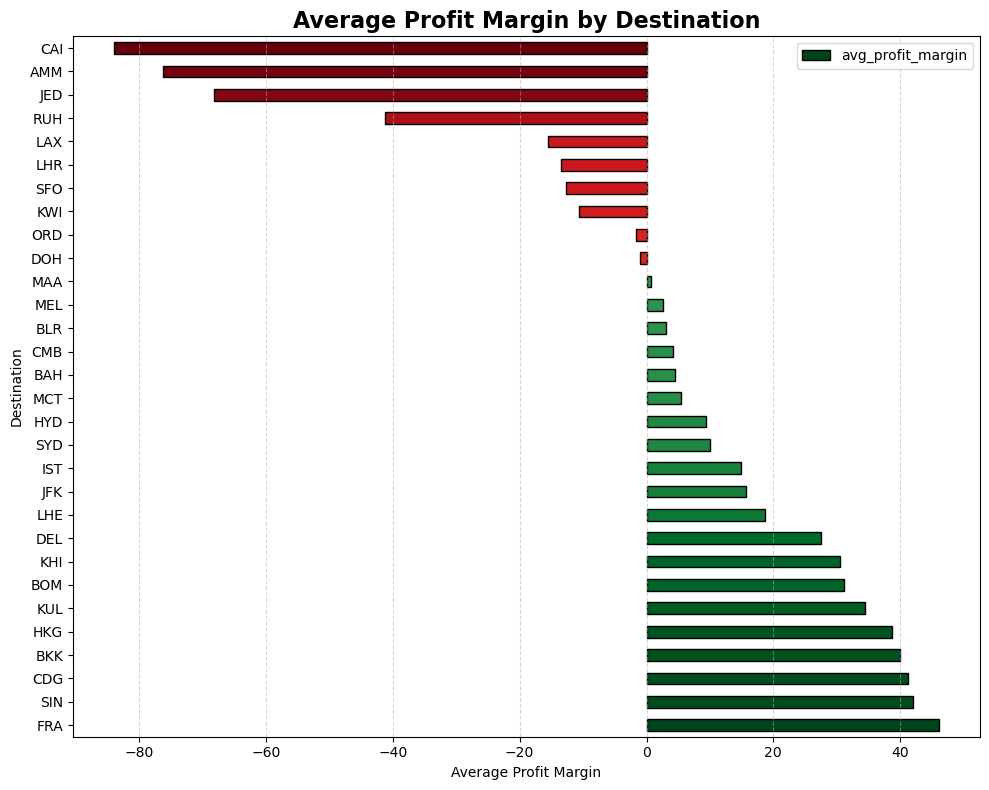


Ranking of Destinations by Total Profit:

Rank 1: FRA - Total Profit = $99,491,502.54
Rank 2: SIN - Total Profit = $90,994,879.30
Rank 3: CDG - Total Profit = $90,178,585.87
Rank 4: HKG - Total Profit = $89,531,878.76
Rank 5: JFK - Total Profit = $41,237,491.55
Rank 6: BKK - Total Profit = $40,563,948.78
Rank 7: KUL - Total Profit = $36,481,521.99
Rank 8: SYD - Total Profit = $31,126,294.37
Rank 9: BOM - Total Profit = $24,070,355.00
Rank 10: DEL - Total Profit = $21,052,229.00
Rank 11: IST - Total Profit = $13,508,781.50
Rank 12: MEL - Total Profit = $7,747,732.31
Rank 13: LHE - Total Profit = $7,033,629.36
Rank 14: KHI - Total Profit = $6,302,688.60
Rank 15: HYD - Total Profit = $4,408,874.00
Rank 16: ORD - Total Profit = $3,868,119.92
Rank 17: CMB - Total Profit = $3,256,570.31
Rank 18: BLR - Total Profit = $2,409,879.55
Rank 19: MAA - Total Profit = $2,141,567.81
Rank 20: MCT - Total Profit = $1,666,944.98
Rank 21: BAH - Total Profit = $1,381,801.44
Rank 22: DOH - Total Profit = $

In [44]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Create gradient colors based on Profit Margin
norm = mcolors.TwoSlopeNorm(
    vmin=route_profitability['avg_profit_margin'].min(),
    vcenter=0,
    vmax=route_profitability['avg_profit_margin'].max()
)

colors = [
    cm.Greens(0.4 + 0.6 * norm(v)) if v >= 0
    else cm.Reds(1 - 0.6 * norm(v))
    for v in route_profitability['avg_profit_margin']
]

# Horizontal Bar Chart
route_profitability.plot(
    x='Destination',
    y='avg_profit_margin',
    kind='barh',
    figsize=(10,8),
    color=colors,
    edgecolor='black'
)

plt.title('Average Profit Margin by Destination', fontsize=16, fontweight='bold')
plt.xlabel('Average Profit Margin')
plt.ylabel('Destination')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Rank destinations by Total Profit
route_profitability["profit_rank"] = (
    route_profitability["total_profit"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# Sort by rank
route_profitability = route_profitability.sort_values("profit_rank")

# Print ranking
print("\nRanking of Destinations by Total Profit:\n")

for _, row in route_profitability.iterrows():
    print(
        f"Rank {row['profit_rank']}: "
        f"{row['Destination']} - "
        f"Total Profit = ${row['total_profit']:,.2f}"
    )

In [17]:
# PART 4: ANALYSIS 3 - SEASONAL IMPACT ON PROFIT  (تأثير الموسم على الأرباح)

season_profitability = (
    df.groupby('Season')
    .agg(
        total_flights=('Profit', 'count'),
        avg_profit_margin=('Profit_Margin', 'mean'),
        avg_load_factor=('Load_Factor', lambda x: x.mean() * 100),
        total_profit=('Profit', 'sum'),
        loss_flights=('Profit', lambda x: (x < 0).sum()),
    )
    .round(2)
    .sort_values('avg_profit_margin', ascending=False)
    .reset_index()
)
print(season_profitability.to_string(index=False))
print()

  Season  total_flights  avg_profit_margin  avg_load_factor   total_profit  loss_flights
    Peak           2002              17.55            86.99 220,778,056.03           450
Shoulder           2646              10.14            82.20 218,758,275.91           785
  Normal           1325               3.33            78.17  84,111,655.63           478
     Low           2001              -8.50            71.93  51,832,673.42           975



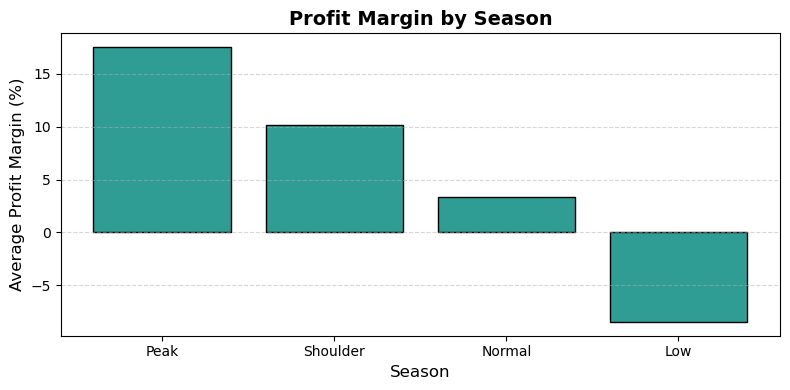

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.bar(
    season_profitability['Season'],
    season_profitability['avg_profit_margin'],
    color='#2F9D94',
    edgecolor='black'
)

plt.title("Profit Margin by Season", fontsize=14, fontweight='bold')
plt.xlabel("Season", fontsize=12)
plt.ylabel("Average Profit Margin (%)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [19]:
# PART 5: ANALYSIS 4 - AIRCRAFT TYPE EFFICIENCY  (كفاءة كل نوع طيارة)

aircraft_performance = (
    df.groupby(['Aircraft_Type', 'Aircraft_Capacity'])
    .agg(
        total_flights=('Profit', 'count'),
        avg_profit_margin=('Profit_Margin', 'mean'),
        avg_load_factor=('Load_Factor', lambda x: x.mean() * 100),
        avg_fuel_cost=('Fuel_Cost', 'mean'),
        total_profit=('Profit', 'sum'),
        loss_flights=('Profit', lambda x: (x < 0).sum()),
    )
    .round(2)
    .sort_values('avg_profit_margin', ascending=False)
    .reset_index()
)
print(aircraft_performance.to_string(index=False))
print()

   Aircraft_Type  Aircraft_Capacity  total_flights  avg_profit_margin  avg_load_factor  avg_fuel_cost   total_profit  loss_flights
     Airbus A380                517            793              23.18            84.78     112,448.15 181,107,004.66           156
Boeing 777-300ER                396           1690              17.26            80.67      80,483.18 195,138,692.13           418
    Boeing 787-9                296           1818               9.48            80.44      34,419.43 133,584,138.92           492
 Airbus A350-900                325           1700               1.04            75.93      42,647.86  62,571,662.38           617
     Airbus A320                180            956              -7.87            81.15       4,434.59   2,044,150.17           473
  Boeing 737-800                189           1017              -9.50            81.31       4,586.25   1,035,012.73           532



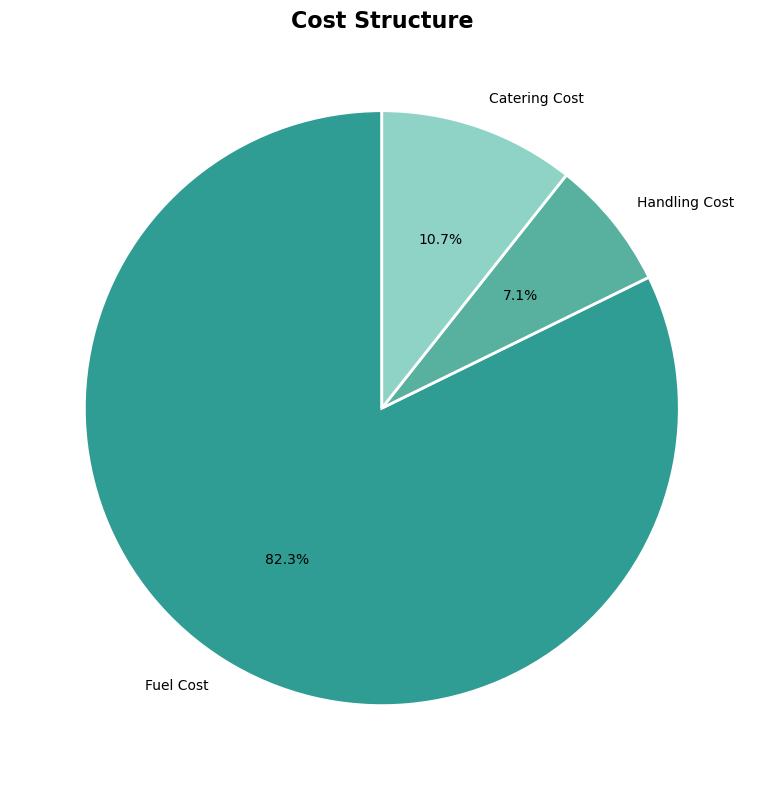

In [20]:
import matplotlib.pyplot as plt

cost_structure = {
    'Fuel Cost': df['Fuel_Cost'].sum(),
    'Handling Cost': df['Handling_Cost'].sum(),
    'Catering Cost': df['Catering_Cost'].sum()
}

# Blue Lagoon color palette
colors = [
    '#2F9D94',  # Dark Teal
    '#58B19F',  # Medium Teal
    '#8FD3C7'   # Light Teal
]

plt.figure(figsize=(8,8))

plt.pie(
    cost_structure.values(),
    labels=cost_structure.keys(),
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    }
)

plt.title(
    'Cost Structure',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [21]:
# PART 8: STATISTICAL ANALYSIS 1 - Z-SCORE OUTLIER DETECTION

df['Profit_Margin_Zscore'] = stats.zscore(df['Profit_Margin'])
df['Is_Outlier_Zscore'] = df['Profit_Margin_Zscore'].abs() > 3

outliers = df[df['Is_Outlier_Zscore']].copy()
print(f"Total outlier flights (|Z| > 3): {len(outliers)} ({len(outliers)/len(df)*100:.2f}% of all flights)")
print()

if len(outliers) > 0:
    outlier_summary = (
        outliers.groupby('Destination')
        .agg(
            outlier_flights=('Profit_Margin', 'count'),
            avg_zscore=('Profit_Margin_Zscore', 'mean'),
            avg_profit_margin=('Profit_Margin', 'mean'),
        )
        .round(2)
        .sort_values('outlier_flights', ascending=False)
        .reset_index()
    )
    print("Outliers by destination:")
    print(outlier_summary.to_string(index=False))
    print()

    print("Top 10 most extreme outlier flights:")
    top_outliers = outliers.reindex(
        outliers['Profit_Margin_Zscore'].abs().sort_values(ascending=False).index
    )[['ID', 'Destination', 'Season', 'Profit_Margin', 'Profit_Margin_Zscore']].head(10)
    print(top_outliers.round(2).to_string(index=False))
print()

zscore_summary = {
    'total_outliers': int(len(outliers)),
    'outlier_pct': round(len(outliers) / len(df) * 100, 2),
    'mean_profit_margin': round(df['Profit_Margin'].mean(), 4),
    'std_profit_margin': round(df['Profit_Margin'].std(), 4),
}

Total outlier flights (|Z| > 3): 149 (1.87% of all flights)

Outliers by destination:
Destination  outlier_flights  avg_zscore  avg_profit_margin
        CAI               55       -4.10            -153.85
        AMM               49       -3.81            -142.46
        JED               37       -3.62            -135.06
        RUH                7       -3.64            -135.91
        KWI                1       -3.07            -113.52

Top 10 most extreme outlier flights:
  ID Destination Season  Profit_Margin  Profit_Margin_Zscore
6872         CAI    Low        -236.27                 -6.21
1396         CAI    Low        -216.97                 -5.72
1150         AMM    Low        -216.64                 -5.71
4208         AMM    Low        -213.96                 -5.64
6901         AMM    Low        -210.39                 -5.55
3741         CAI Normal        -209.95                 -5.54
3524         CAI    Low        -209.91                 -5.54
6936         CAI    Low     

In [22]:
# PART 9: STATISTICAL ANALYSIS 2 - ONE-WAY ANOVA

anova_results = {}

# ANOVA 1: Profit Margin across Seasons
groups_season = [g['Profit_Margin'].values for _, g in df.groupby('Season')]
f_stat, p_val = stats.f_oneway(*groups_season)
anova_results['season'] = {'f_statistic': round(f_stat, 4), 'p_value': p_val, 'significant': bool(p_val < 0.05)}
print(f"1) Profit_Margin ~ Season:")
print(f"   F-statistic = {f_stat:.4f}, p-value = {p_val:.2e}")
print(f"   {'SIGNIFICANT' if p_val < 0.05 else 'NOT significant'} (alpha=0.05): season has a {'real' if p_val<0.05 else 'no real'} effect on profit margin")
print()

# ANOVA 2: Profit Margin across Route Categories
groups_route = [g['Profit_Margin'].values for _, g in df.groupby('Route_Category')]
f_stat2, p_val2 = stats.f_oneway(*groups_route)
anova_results['route_category'] = {'f_statistic': round(f_stat2, 4), 'p_value': p_val2, 'significant': bool(p_val2 < 0.05)}
print(f"2) Profit_Margin ~ Route_Category:")
print(f"   F-statistic = {f_stat2:.4f}, p-value = {p_val2:.2e}")
print(f"   {'SIGNIFICANT' if p_val2 < 0.05 else 'NOT significant'} (alpha=0.05): route category has a {'real' if p_val2<0.05 else 'no real'} effect on profit margin")
print()

# ANOVA 3: Profit Margin across Aircraft Types
groups_aircraft = [g['Profit_Margin'].values for _, g in df.groupby('Aircraft_Type')]
f_stat3, p_val3 = stats.f_oneway(*groups_aircraft)
anova_results['aircraft_type'] = {'f_statistic': round(f_stat3, 4), 'p_value': p_val3, 'significant': bool(p_val3 < 0.05)}
print(f"3) Profit_Margin ~ Aircraft_Type:")
print(f"   F-statistic = {f_stat3:.4f}, p-value = {p_val3:.2e}")
print(f"   {'SIGNIFICANT' if p_val3 < 0.05 else 'NOT significant'} (alpha=0.05): aircraft type has a {'real' if p_val3<0.05 else 'no real'} effect on profit margin")
print()

1) Profit_Margin ~ Season:
   F-statistic = 172.7958, p-value = 1.55e-108
   SIGNIFICANT (alpha=0.05): season has a real effect on profit margin

2) Profit_Margin ~ Route_Category:
   F-statistic = 1473.0159, p-value = 0.00e+00
   SIGNIFICANT (alpha=0.05): route category has a real effect on profit margin

3) Profit_Margin ~ Aircraft_Type:
   F-statistic = 133.6419, p-value = 1.89e-136
   SIGNIFICANT (alpha=0.05): aircraft type has a real effect on profit margin



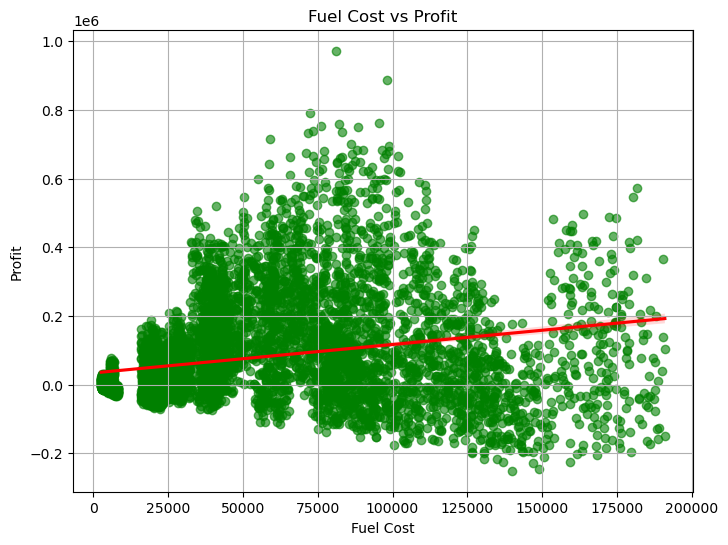

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='Fuel_Cost',
    y='Profit',
    scatter_kws={'alpha':0.6, 'color':'green'},
    line_kws={'color':'red'}
)

plt.title('Fuel Cost vs Profit')
plt.xlabel('Fuel Cost')
plt.ylabel('Profit')

plt.grid(True)

plt.show()

In [24]:
# PART 10: STATISTICAL ANALYSIS 3 - PEARSON CORRELATION

pearson_results = {}

pairs = [
    ('Load_Factor', 'Profit_Margin', 'Load Factor vs Profit Margin'),
    ('Flight_Hours', 'Profit_Margin', 'Flight Hours vs Profit Margin'),
    ('Total_Revenue', 'Total_Cost', 'Total Revenue vs Total Cost'),
    ('Passengers', 'Profit', 'Passengers vs Profit'),
    ('Fuel_Cost', 'Profit_Margin', 'Fuel Cost vs Profit Margin'),
]

for col_x, col_y, label in pairs:
    r, p = stats.pearsonr(df[col_x], df[col_y])
    pearson_results[label] = {'r': round(r, 4), 'p_value': p}
    strength = (
        'very strong' if abs(r) >= 0.8 else
        'strong' if abs(r) >= 0.6 else
        'moderate' if abs(r) >= 0.4 else
        'weak' if abs(r) >= 0.2 else
        'very weak / none'
    )
    direction = 'positive' if r > 0 else 'negative'
    print(f"{label}: r = {r:.4f}  (p = {p:.2e})  -> {strength} {direction} correlation")

print()

# Full correlation matrix for key numeric variables
print("Correlation matrix (key variables):")
corr_cols = ['Load_Factor', 'Flight_Hours', 'Passengers', 'Total_Revenue',
             'Total_Cost', 'Fuel_Cost', 'Profit', 'Profit_Margin']
corr_matrix = df[corr_cols].corr(method='pearson').round(3)
print(corr_matrix.to_string())
print()

Load Factor vs Profit Margin: r = 0.4158  (p = 0.00e+00)  -> moderate positive correlation
Flight Hours vs Profit Margin: r = 0.1097  (p = 8.75e-23)  -> very weak / none positive correlation
Total Revenue vs Total Cost: r = 0.8850  (p = 0.00e+00)  -> very strong positive correlation
Passengers vs Profit: r = 0.5453  (p = 0.00e+00)  -> moderate positive correlation
Fuel Cost vs Profit Margin: r = 0.1423  (p = 2.49e-37)  -> very weak / none positive correlation

Correlation matrix (key variables):
               Load_Factor  Flight_Hours  Passengers  Total_Revenue  Total_Cost  Fuel_Cost  Profit  Profit_Margin
Load_Factor           1.00         -0.06        0.37           0.26        0.10       0.02    0.37           0.42
Flight_Hours         -0.06          1.00        0.51           0.67        0.89       0.91    0.16           0.11
Passengers            0.37          0.51        1.00           0.80        0.79       0.72    0.55           0.36
Total_Revenue         0.26          0.67   

In [25]:
# PART 6: ANALYSIS 5 - LOAD FACTOR vs PROFIT  (علاقة نسبة الامتلاء بالربح)

def load_factor_bucket(lf):
    if lf < 0.60:
        return 'Below 60%'
    elif lf < 0.70:
        return '60% - 70%'
    elif lf < 0.80:
        return '70% - 80%'
    elif lf < 0.90:
        return '80% - 90%'
    else:
        return 'Above 90%'

df['Load_Factor_Bucket'] = df['Load_Factor'].apply(load_factor_bucket)
_bucket_order = ['Below 60%', '60% - 70%', '70% - 80%', '80% - 90%', 'Above 90%']

load_factor_analysis = (
    df.groupby('Load_Factor_Bucket')
    .agg(
        total_flights=('Profit', 'count'),
        avg_profit_margin=('Profit_Margin', 'mean'),
        avg_revenue=('Total_Revenue', 'mean'),
        avg_cost=('Total_Cost', 'mean'),
        loss_flights=('Profit', lambda x: (x < 0).sum()),
    )
    .round(2)
    .reindex(_bucket_order)
    .sort_values('avg_profit_margin', ascending=False)
    .reset_index()
)
print(load_factor_analysis.to_string(index=False))
print()

Load_Factor_Bucket  total_flights  avg_profit_margin  avg_revenue   avg_cost  loss_flights
         Above 90%           1271              26.54   400,983.32 248,920.58           172
         80% - 90%           2757              16.18   336,845.79 237,692.44           648
         70% - 80%           2867              -0.95   255,647.37 215,174.85          1206
         60% - 70%           1040             -23.51   186,846.44 192,403.95           635
         Below 60%             39             -46.16   157,981.58 194,180.84            27



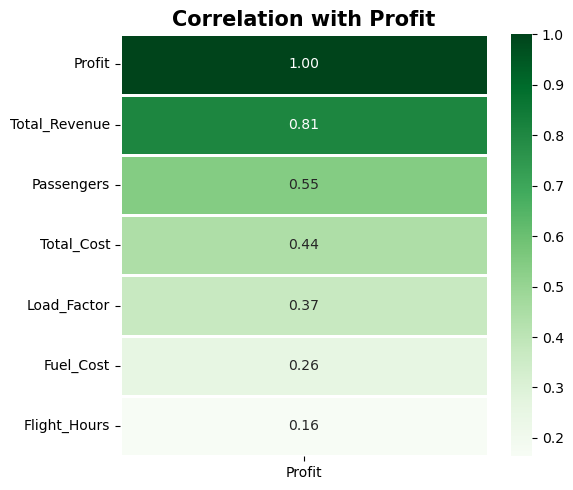

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

profit_corr = df[
    [
        'Profit',
        'Total_Revenue',
        'Total_Cost',
        'Fuel_Cost',
        'Passengers',
        'Flight_Hours',
        'Load_Factor'
    ]
].corr()[['Profit']].sort_values(by='Profit', ascending=False)

plt.figure(figsize=(6,5))

sns.heatmap(
    profit_corr,
    annot=True,
    cmap='Greens',
    fmt='.2f',
    linewidths=1
)

plt.title('Correlation with Profit', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

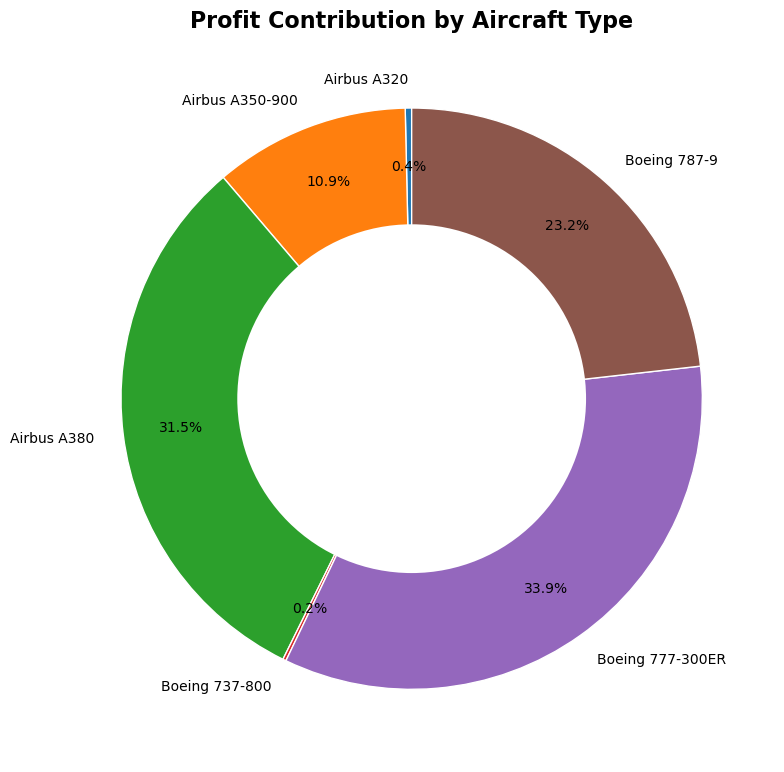

In [27]:
import matplotlib.pyplot as plt

aircraft_profit = df.groupby('Aircraft_Type')['Profit'].sum().reset_index()

colors = [
    '#1f77b4',
    '#ff7f0e',
    '#2ca02c',
    '#d62728',
    '#9467bd',
    '#8c564b',
    '#e377c2',
    '#17becf'
]

plt.figure(figsize=(8,8))

plt.pie(
    aircraft_profit['Profit'],
    labels=aircraft_profit['Aircraft_Type'],
    colors=colors[:len(aircraft_profit)],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
    wedgeprops={'edgecolor':'white'}
)

# Create the hole
centre_circle = plt.Circle((0,0),0.60,fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Profit Contribution by Aircraft Type',
          fontsize=16,
          fontweight='bold')

plt.tight_layout()
plt.show()

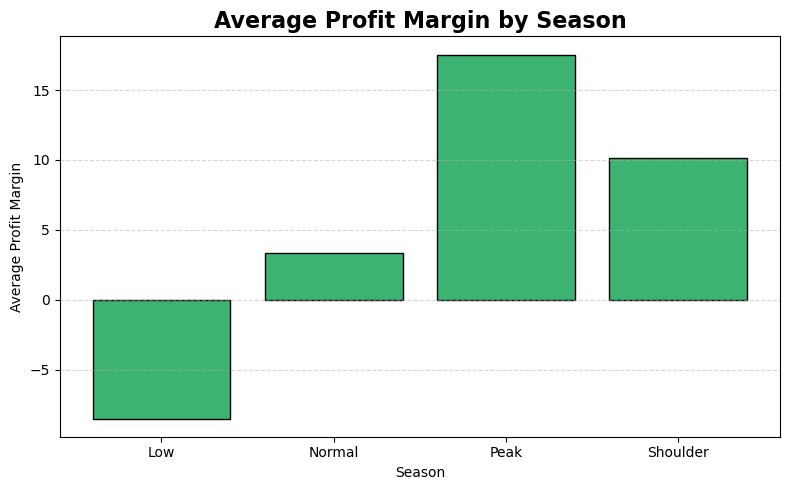

In [28]:
import matplotlib.pyplot as plt

season_profit = df.groupby('Season')['Profit_Margin'].mean()

plt.figure(figsize=(8,5))

plt.bar(
    season_profit.index,
    season_profit.values,
    color='mediumseagreen',
    edgecolor='black'
)

plt.title('Average Profit Margin by Season', fontsize=16, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Average Profit Margin')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<Axes: >

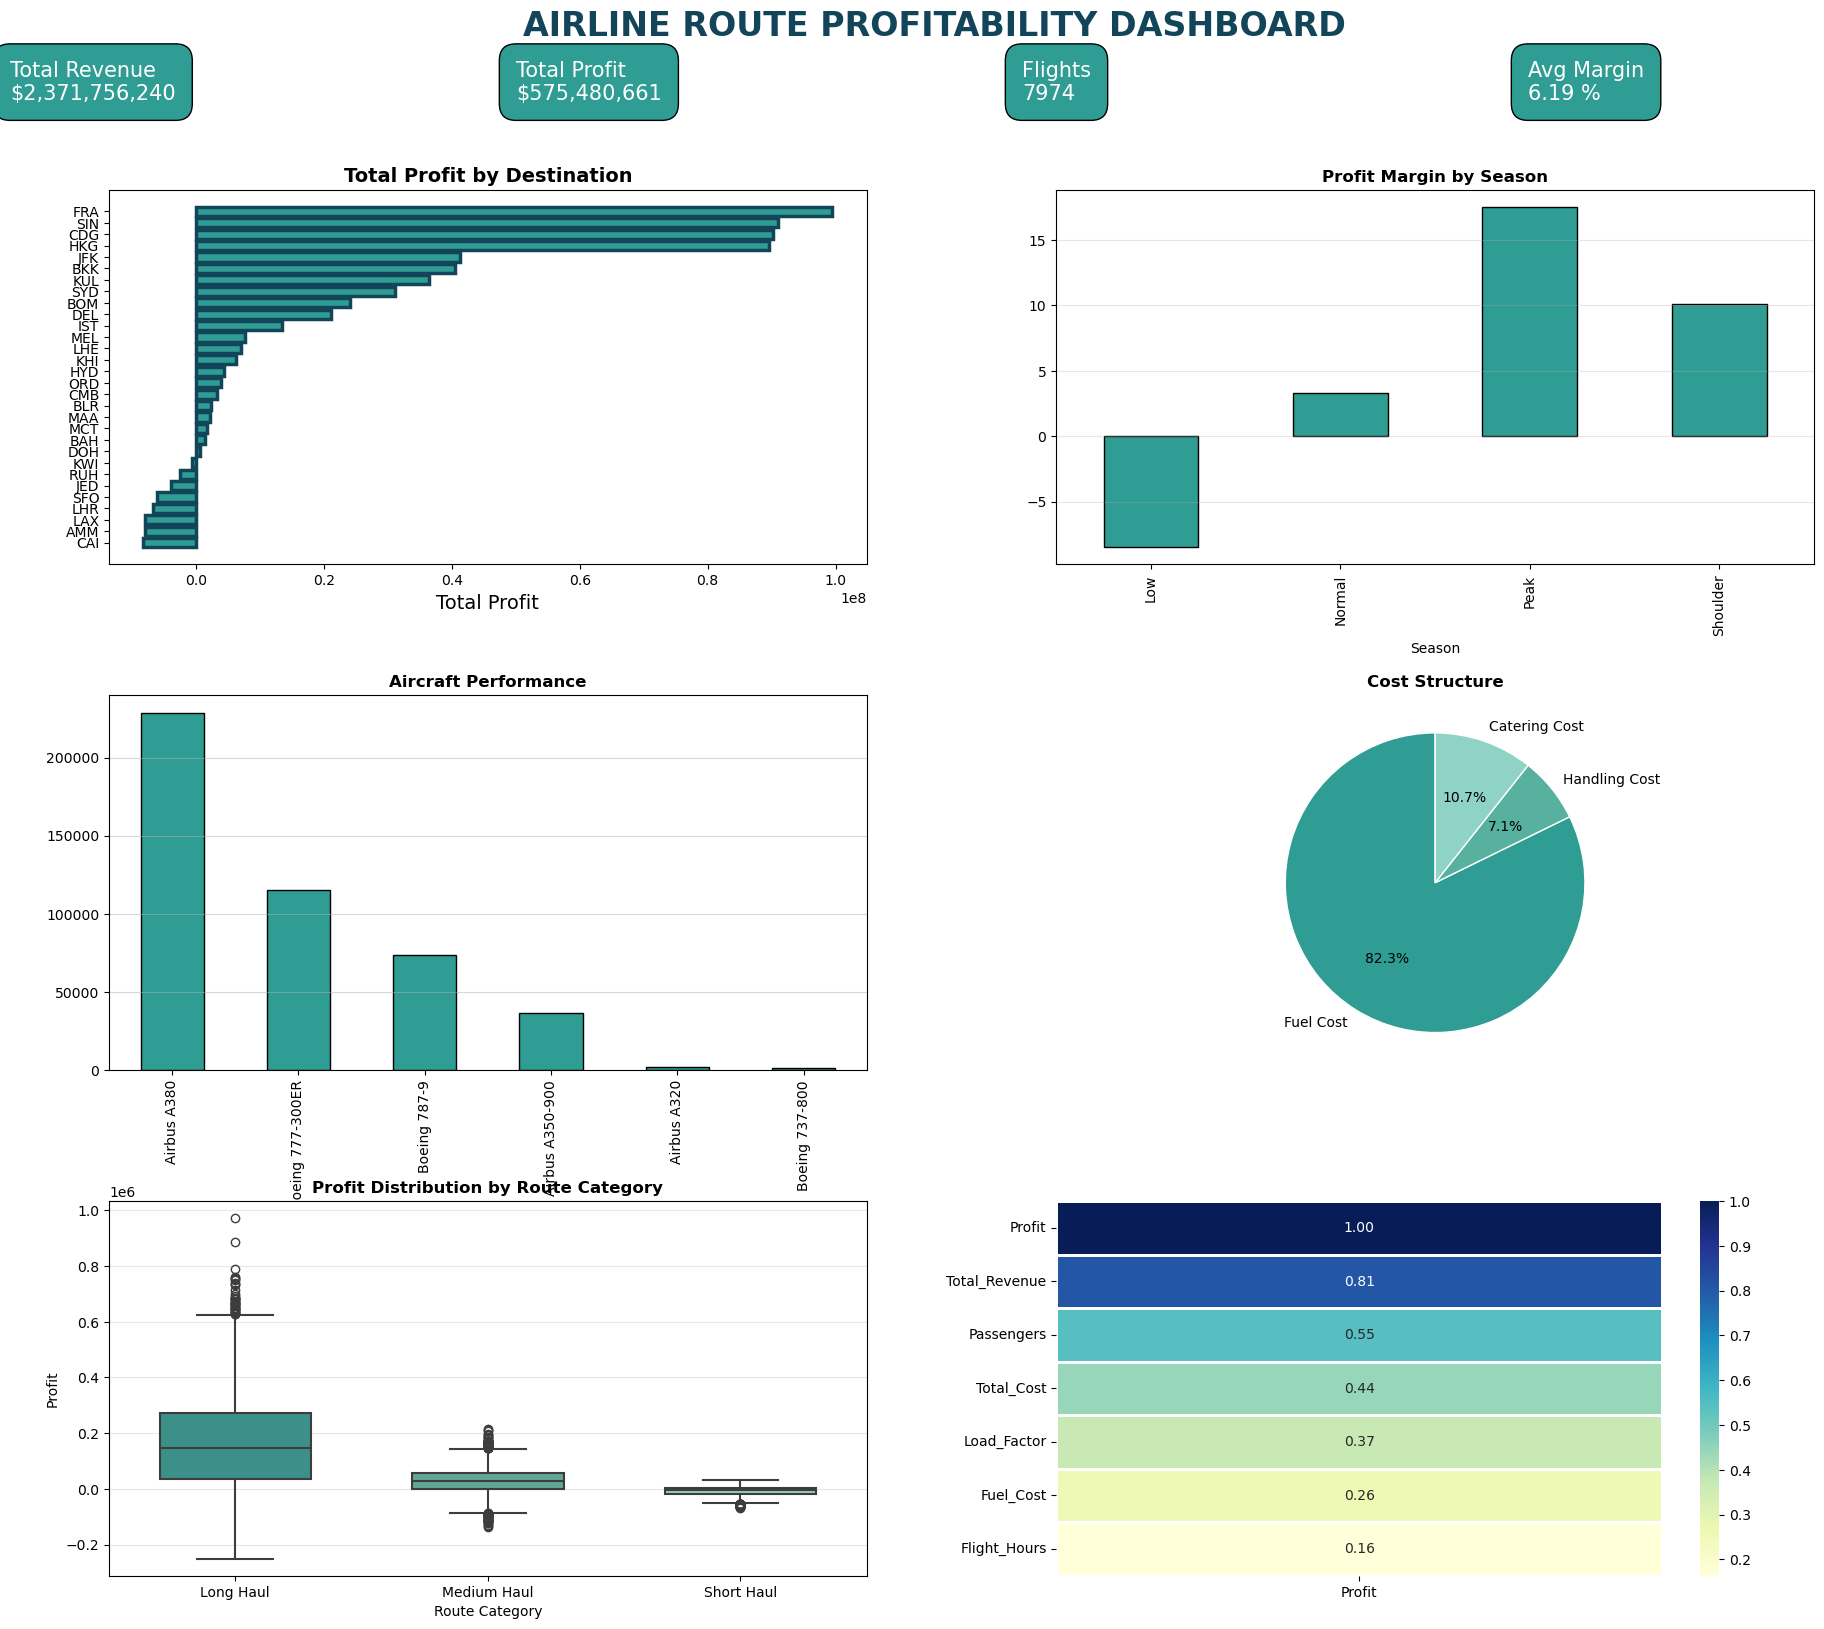

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

#=========================================================
# KPI
#=========================================================

total_revenue = df["Total_Revenue"].sum()
total_profit = df["Profit"].sum()
total_flights = len(df)
avg_margin = df["Profit_Margin"].mean()

#=========================================================
# Prepare Data
#=========================================================

destination_profit = (
    df.groupby("Destination")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

season_margin = (
    df.groupby("Season")["Profit_Margin"]
      .mean()
)

aircraft_profit = (
    df.groupby("Aircraft_Type")["Profit"]
      .mean()
      .sort_values(ascending=False)
)

cost_structure = {
    "Fuel Cost": df["Fuel_Cost"].sum(),
    "Handling Cost": df["Handling_Cost"].sum(),
    "Catering Cost": df["Catering_Cost"].sum()
}

corr = df[
[
"Profit",
"Total_Revenue",
"Total_Cost",
"Fuel_Cost",
"Passengers",
"Flight_Hours",
"Load_Factor"
]
].corr()

#=========================================================
# Dashboard
#=========================================================

fig = plt.figure(figsize=(22,18))

fig.suptitle(
    "AIRLINE ROUTE PROFITABILITY DASHBOARD",
    fontsize=24,
    fontweight="bold",
    color="#124559"
)

#=========================================================
# KPI Cards
#=========================================================

card_color = "#2F9D94"

fig.text(
0.08,
0.93,
f"Total Revenue\n${total_revenue:,.0f}",
fontsize=15,
color="white",
bbox=dict(boxstyle="round,pad=0.8",facecolor=card_color)
)

fig.text(
0.31,
0.93,
f"Total Profit\n${total_profit:,.0f}",
fontsize=15,
color="white",
bbox=dict(boxstyle="round,pad=0.8",facecolor=card_color)
)

fig.text(
0.54,
0.93,
f"Flights\n{total_flights}",
fontsize=15,
color="white",
bbox=dict(boxstyle="round,pad=0.8",facecolor=card_color)
)

fig.text(
0.77,
0.93,
f"Avg Margin\n{avg_margin:.2f} %",
fontsize=15,
color="white",
bbox=dict(boxstyle="round,pad=0.8",facecolor=card_color)
)

#=========================================================
# Charts Layout
#=========================================================

gs = fig.add_gridspec(3,2,hspace=0.35,wspace=0.25)

#---------------------------------------------------------
#---------------------------------------------------------
# Total Profit by Destination (Horizontal Bar Chart)
#---------------------------------------------------------

ax1 = fig.add_subplot(gs[0,0])

ax1.barh(
    destination_profit.index,
    destination_profit.values,
    color="#2F9D94",
    edgecolor="#124559",
    linewidth=2.5
)

# Display the highest profit at the top
ax1.invert_yaxis()

ax1.set_title(
    "Total Profit by Destination",
    fontsize=14,
    fontweight="bold"
)

ax1.set_xlabel(
    "Total Profit",
    fontsize=14
)
#---------------------------------------------------------
# Season
#---------------------------------------------------------

ax2 = fig.add_subplot(gs[0,1])

season_margin.plot(
kind="bar",
color="#2F9D94",
edgecolor="black",
ax=ax2
)

ax2.set_title("Profit Margin by Season",fontweight="bold")
ax2.grid(axis="y",alpha=.3)

#---------------------------------------------------------
# Aircraft
#---------------------------------------------------------

ax3 = fig.add_subplot(gs[1,0])

aircraft_profit.plot(
kind="bar",
color="#2F9D94",
edgecolor="black",
ax=ax3
)

ax3.set_title("Aircraft Performance",fontweight="bold")
ax3.grid(axis="y",alpha=.5)

#---------------------------------------------------------
# Cost Structure
#---------------------------------------------------------

ax4 = fig.add_subplot(gs[1,1])

colors = [
"#2F9D94",
"#58B19F",
"#8FD3C7"
]

ax4.pie(
cost_structure.values(),
labels=cost_structure.keys(),
colors=colors,
autopct="%1.1f%%",
startangle=90,
wedgeprops=dict(edgecolor="white")
)

ax4.set_title("Cost Structure",fontweight="bold")

#---------------------------------------------------------
# Scatter
#---------------------------------------------------------



ax5 = fig.add_subplot(gs[2,0])

sns.boxplot(
    data=df,
    x='Route_Category',
    y='Profit',
    palette=['#2F9D94', '#58B19F', '#8FD3C7'],
    width=0.6,
    linewidth=1.5,
    ax=ax5
)

ax5.set_title("Profit Distribution by Route Category", fontweight='bold')
ax5.set_xlabel("Route Category")
ax5.set_ylabel("Profit")
ax5.grid(axis='y', alpha=0.3)

#---------------------------------------------------------
# Correlation
#---------------------------------------------------------

ax6 = fig.add_subplot(gs[2,1])

profit_corr = df[
    [
        'Profit',
        'Total_Revenue',
        'Total_Cost',
        'Fuel_Cost',
        'Passengers',
        'Flight_Hours',
        'Load_Factor'
    ]
].corr()[['Profit']].sort_values(by='Profit', ascending=False)

sns.heatmap(
    profit_corr,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f',
    linewidths=1,
    cbar=True,
    ax=ax6
)

In [30]:
from scipy.stats import spearmanr

corr, p = spearmanr(df['Flight_Hours'], df['Profit'])

print("Spearman Correlation:", corr)
print("P-value:", p)

Spearman Correlation: 0.3010485368136517
P-value: 1.0272171027053825e-166


In [31]:
from scipy.stats import spearmanr

corr, p = spearmanr(df['Load_Factor'], df['Profit'])

print("Spearman Correlation:", corr)
print("P-value:", p)

Spearman Correlation: 0.387092929766313
P-value: 2.242712389532122e-283


In [32]:

corr, p = spearmanr(df['Passengers'], df['Profit'])
print("Spearman Correlation:", corr)
print("P-value:", p)

Spearman Correlation: 0.4928536113769427
P-value: 0.0


In [39]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

#=========================================================
# Prepare Data
#=========================================================

# Average Profit Margin by Destination
route_profitability = (
    df.groupby("Destination")
      .agg(
          avg_profit_margin=("Profit_Margin", "mean"),
          total_profit=("Profit", "sum")
      )
      .reset_index()
)

# Ranking
route_profitability["profit_rank"] = (
    route_profitability["total_profit"]
    .rank(method="min", ascending=False)
    .astype(int)
)

route_profitability = route_profitability.sort_values(
    "avg_profit_margin",
    ascending=True
)

# Gradient Colors
norm = mcolors.TwoSlopeNorm(
    vmin=route_profitability["avg_profit_margin"].min(),
    vcenter=0,
    vmax=route_profitability["avg_profit_margin"].max()
)

gradient_colors = [
    cm.Greens(0.4 + 0.6 * norm(v))
    if v >= 0
    else cm.Reds(1 - 0.6 * norm(v))
    for v in route_profitability["avg_profit_margin"]
]

# Season
season_margin = (
    df.groupby("Season")["Profit_Margin"]
      .mean()
)

# Aircraft
aircraft_profit = (
    df.groupby("Aircraft_Type")["Profit"]
      .mean()
      .sort_values(ascending=False)
)

# Cost Structure
cost_structure = {
    "Fuel Cost": df["Fuel_Cost"].sum(),
    "Handling Cost": df["Handling_Cost"].sum(),
    "Catering Cost": df["Catering_Cost"].sum()
}

# Correlation with Profit
profit_corr = df[
    [
        "Profit",
        "Total_Revenue",
        "Total_Cost",
        "Fuel_Cost",
        "Passengers",
        "Flight_Hours",
        "Load_Factor"
    ]
].corr()[["Profit"]].sort_values(
    by="Profit",
    ascending=False
)